In [ ]:
#######################################################################
# Copyright (C)                                                       #
# 2016-2018 Shangtong Zhang(zhangshangtong.cpp@gmail.com)             #
# 2016 Kenta Shimada(hyperkentakun@gmail.com)                         #
# Permission given to modify the code as long as you keep this        #
# declaration at the top                                              #
#######################################################################
# Policy iteration and policy visualisation by Peter Lacko
#

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.table import Table
import copy

matplotlib.use('Agg')
%matplotlib inline

WORLD_SIZE = 4

ACTIONS = [(0, -1),
           (-1, 0),
           (0, 1),
           (1, 0)]

ACTIONSVIS = {(0, -1):'<',
           (-1, 0):'^',
           (0, 1):'>',
           (1, 0):'v'}

ACTION_PROB = 0.25

badStates = []

def is_terminal(state):
    x, y = state
    return (x == 0 and y == 0) or (x == WORLD_SIZE-1 and y == WORLD_SIZE-1)

def step(state, action):
    if is_terminal(state):
        return state, 0

    next_state = (np.array(state) + np.array(action)).tolist()
    x, y = next_state

    if x < 0 or x >= WORLD_SIZE or y < 0 or y >= WORLD_SIZE:
        next_state = state

    x, y = next_state
    if (x, y) in badStates:
      reward = -10
    else:
      reward = -1

    return next_state, reward


def draw_image(image):
    fig, ax = plt.subplots()
    ax.set_axis_off()
    tb = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = image.shape
    width, height = 1.0 / ncols, 1.0 / nrows

    # Add cells
    for (i, j), val in np.ndenumerate(image):
      if is_terminal((i, j)):
        tb.add_cell(i, j, width, height, text=val,
                    loc='center', facecolor='lightblue')
      else:
        tb.add_cell(i, j, width, height, text=val,
                    loc='center', facecolor='white')

        # Row and column labels...
    for i in range(len(image)):
        tb.add_cell(i, -1, width, height, text=i+1, loc='right',
                    edgecolor='none', facecolor='none')
        tb.add_cell(-1, i, width, height/2, text=i+1, loc='center',
                    edgecolor='none', facecolor='none')
    ax.add_table(tb)

def draw_image2(image):
    fig, ax = plt.subplots()
    ax.set_axis_off()
    tb = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = image.shape
    width, height = 1.0 / ncols, 1.0 / nrows

    # Add cells
    for (i, j), val in np.ndenumerate(image):
      if (i, j) in badStates:
        tb.add_cell(i, j, width, height, text=val,
                    loc='center', facecolor='lightsalmon')
      else:
        tb.add_cell(i, j, width, height, text=val,
                    loc='center', facecolor='white')

        # Row and column labels...
    for i in range(len(image)):
        tb.add_cell(i, -1, width, height, text=i+1, loc='right',
                    edgecolor='none', facecolor='none')
        tb.add_cell(-1, i, width, height/2, text=i+1, loc='center',
                    edgecolor='none', facecolor='none')
    ax.add_table(tb)


Random policy
In-place: 140 iterations
Synchronous: 214 iterations


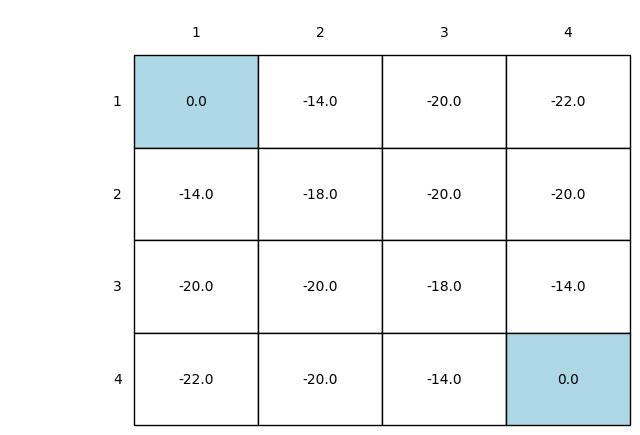

Up-Left policy
In-place: 24 iterations
Synchronous: 26 iterations


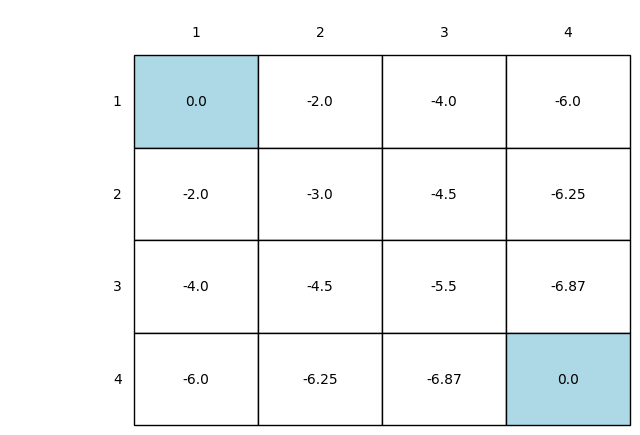

In [ ]:
badStates = []

def compute_state_value(pi, in_place=True, discount=1.0):
    new_state_values = np.zeros((WORLD_SIZE, WORLD_SIZE))
    iteration = 0
    while True:
        if in_place:
            state_values = new_state_values
        else:
            state_values = new_state_values.copy()
        old_state_values = state_values.copy()

        for i in range(WORLD_SIZE):
            for j in range(WORLD_SIZE):
                value = 0
                for action in ACTIONS:
                    (next_i, next_j), reward = step([i, j], action)
                    # Add state value computation
                    # reward
                    # discount
                    # pi[(i, j)][action]
                    # state_values
                    # why pi is here? because we need to compute expected value of action, not just value of best action
                    # why state_values is here? because we need to compute value of next state, not just reward of action
                    value += pi[(i, j)][action] * (reward + discount * state_values[next_i, next_j])

                # if we use inplace, we update state values immediately, otherwise we update them after we compute all new state values
                # result of inplace is that we use new state values for next states, while in synchronous we use old state values for next states
                # can it be fastet if we update state values immediately? yes, because we use new state values for next states, while in synchronous we use old state values for next states, so we can converge faster
                new_state_values[i, j] = value

        max_delta_value = abs(old_state_values - new_state_values).max()
        if max_delta_value < 1e-5:
            break

        iteration += 1

    return new_state_values, iteration


def policyEvaluation(pi):
    values, sync_iteration = compute_state_value(pi, in_place=False, discount=1)
    values, asycn_iteration = compute_state_value(pi, in_place=True, discount=1)

    draw_image(np.round(values, decimals=2))
    print('In-place: {} iterations'.format(asycn_iteration))
    print('Synchronous: {} iterations'.format(sync_iteration))

    plt.show()

#initialize random policy
def initRandomPi():
  pi = {}
  for i in range(WORLD_SIZE):
    for j in range(WORLD_SIZE):
      pi[(i, j)] = {}
      for action in ACTIONS:
        pi[(i, j)][action] = 0.25
  return pi

def initUpLeftPi():
  pi = {}
  for i in range(WORLD_SIZE):
    for j in range(WORLD_SIZE):
      pi[(i, j)] = {}
      pi[(i, j)][ACTIONS[0]] = 0.5
      pi[(i, j)][ACTIONS[1]] = 0.5
      pi[(i, j)][ACTIONS[2]] = 0
      pi[(i, j)][ACTIONS[3]] = 0
  return pi

print("Random policy")
pi = initRandomPi()
policyEvaluation(pi)

print("Up-Left policy")
pi = initUpLeftPi()
policyEvaluation(pi)


--------------------------------------------------------------------------
Epoch:  1


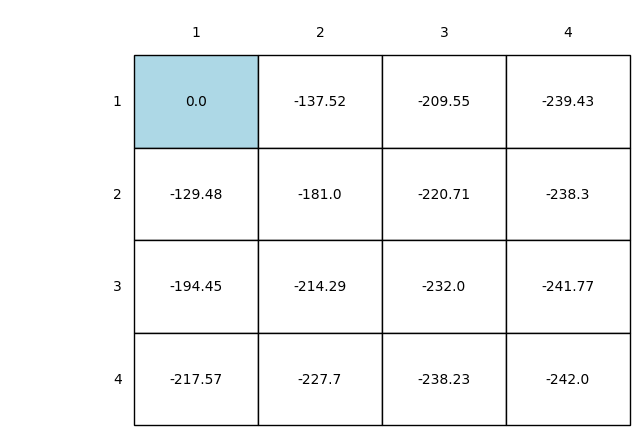

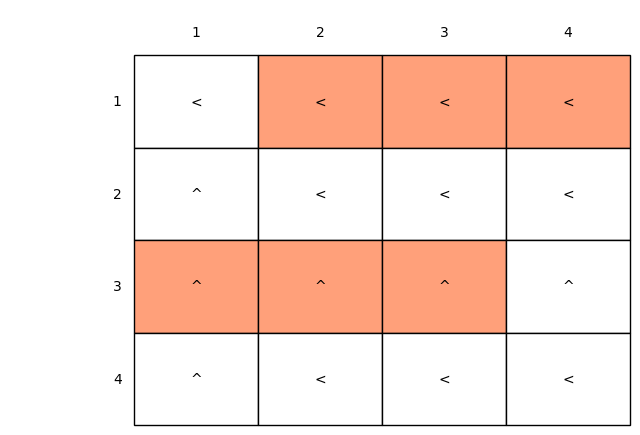

--------------------------------------------------------------------------
Epoch:  2


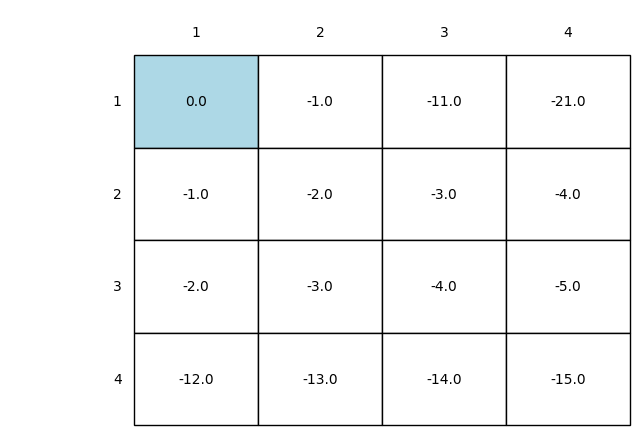

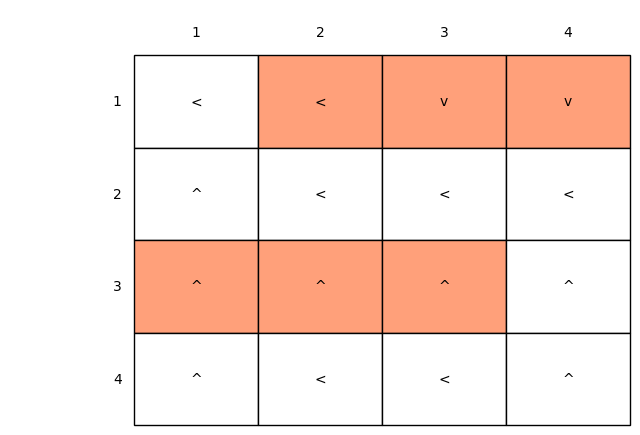

--------------------------------------------------------------------------
Epoch:  3


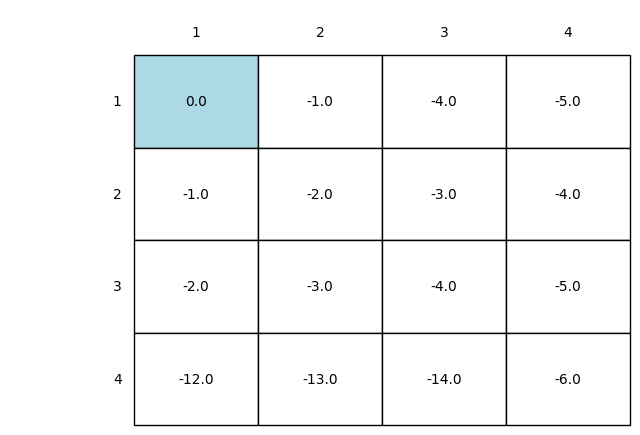

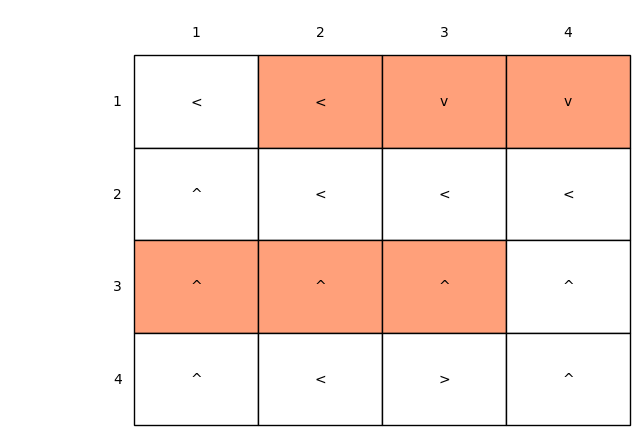

--------------------------------------------------------------------------
Epoch:  4


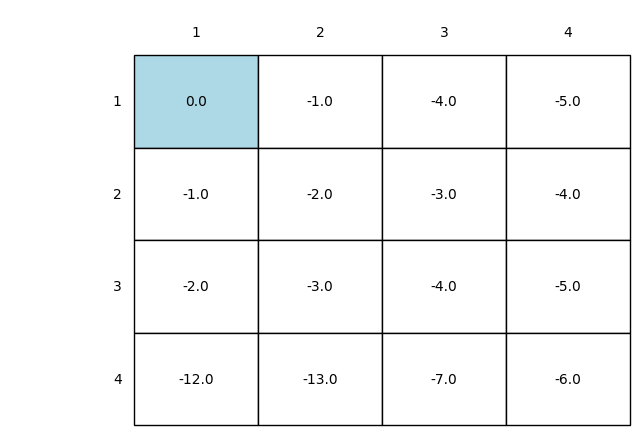

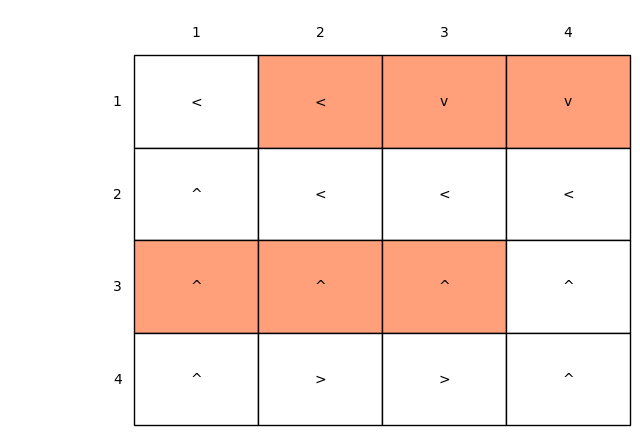

--------------------------------------------------------------------------
Epoch:  5


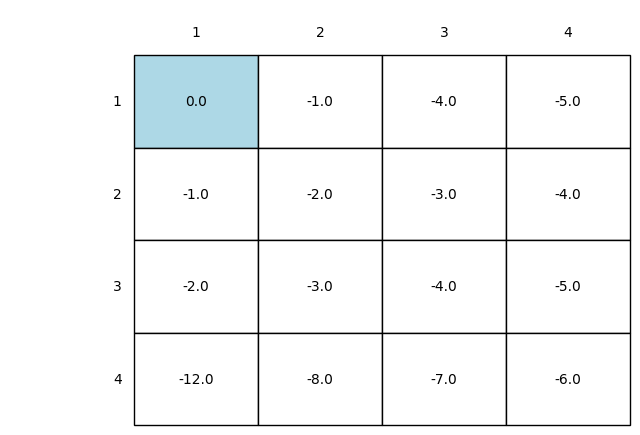

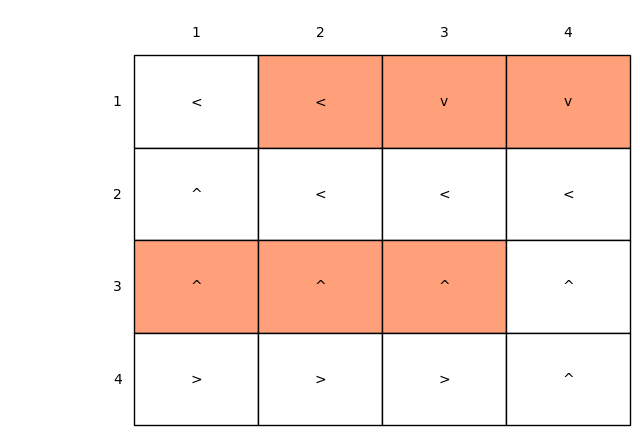

--------------------------------------------------------------------------
Epoch:  6


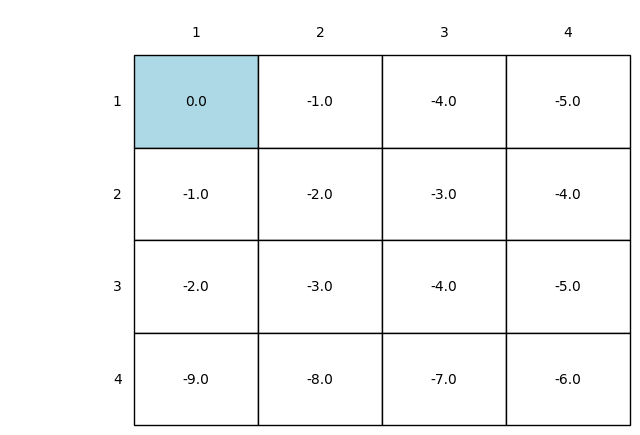

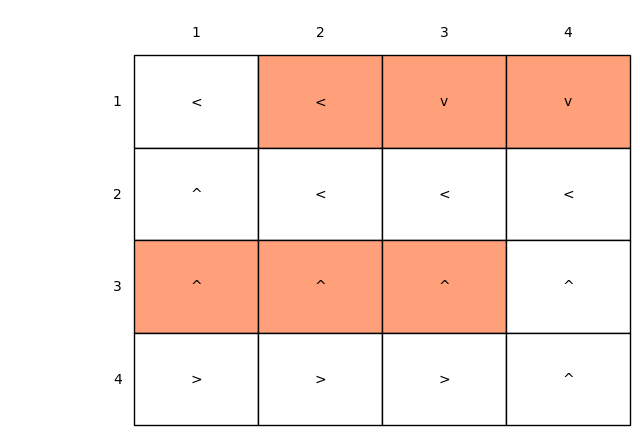

In [ ]:
badStates = [(0, 1),
           (0, 2),
           (0, 3),
           (2, 0),
           (2, 1),
           (2, 2),]

def is_terminal(state):
    x, y = state
    return (x == 0 and y == 0)

def policyEvaluation(pi, discount):
    values, asycn_iteration = compute_state_value(pi, in_place=True, discount=discount)
    draw_image(np.round(values, decimals=2))
    plt.show()
    return values

def policyImprovement(pi, discount=1.0):
    values = policyEvaluation(pi, discount)
    npi = {}
    pp = np.zeros((WORLD_SIZE, WORLD_SIZE), dtype='U1')
    for i in range(WORLD_SIZE):
      for j in range(WORLD_SIZE):
        npi[(i, j)] = {}
        maxValue = -np.inf
        maxA = ACTIONS[0]
        for action in ACTIONS:
          npi[(i, j)][action] = 0
          (next_i, next_j), reward = step([i, j], action)
          # why reward + DISCOUNT * value[next_i, next_j] ? ... Bellman optimality equation, 
          # the value of a state is the maximum expected return of taking an action from that state, 
          # which is the immediate reward plus the discounted value of the next state
          value = reward + discount * values[next_i, next_j]
          # we select the action with the highest value, which is the best action to take in that state according to the current policy
          if value > maxValue:
            maxValue = value
            maxA = action
          


        npi[(i, j)][maxA] = 1
        pp[i, j] = ACTIONSVIS[maxA]

    draw_image2(pp);
    plt.show()
    return npi

def policyIteration():
  pi = initRandomPi()
  epoch = 1;
  while (True):
    print("--------------------------------------------------------------------------")
    print("Epoch: ", epoch)
    epoch += 1
    newPi = policyImprovement(pi)
    if newPi == pi:
      return
    else:
      pi = copy.deepcopy(newPi)

policyIteration()